# Import libraries

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import seaborn as sns

from matplotlib import gridspec

from matplotlib.colors import ListedColormap

from scipy.signal import find_peaks

In [2]:
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 50)

In [3]:
sns.set_theme()

mpl.rcParams.update({
    "font.family": ["Comic Sans MS", "DejaVu Sans", "Arial"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
path_to_save = './../results/00b_frac_mass_ratios'

# Loading data

In [5]:
path_to_data= './../data/additional_data/mass_ratios/fractions_ratios.xlsx'

In [6]:
data_mass = pd.read_excel(path_to_data, sheet_name=None)

print(len(data_mass.keys()))

10


# Fractions distribution by mass

In [7]:
type_color_dict = {
    r'$d \leq 2$': '#2166AC',
    r'$2 < d \leq 5$': '#67A9CF',
    r'$d > 5$': '#B2182B'
}

## Data wrangling

### Merging tables

In [8]:
fractions_ratios_df = pd.DataFrame()

for fractionation_id, table in data_mass.items():
    table['fractionation_id'] = fractionation_id
    fractions_ratios_df = pd.concat([fractions_ratios_df, table], axis=0)

print(fractions_ratios_df.shape)
fractions_ratios_df.head(3)

(74, 4)


,ID,size,ratio,fractionation_id
0,1,>5,0.327407,1
1,2,>3,0.133301,1
2,3,>2.5,0.441274,1


### Column names correction

In [9]:
columns_dict = {
    'fractionation_id': 'fractionation_id',
    'ID': 'id',
    'size': 'size',
    'ratio': 'ratio'
}

In [10]:
fractions_ratios_df = fractions_ratios_df.rename(columns=columns_dict)[columns_dict.values()]

print(fractions_ratios_df.shape)
fractions_ratios_df.head(3)

(74, 4)


,fractionation_id,id,size,ratio
0,1,1,>5,0.327407
1,1,2,>3,0.133301
2,1,3,>2.5,0.441274


In [11]:
fractions_ratios_df['size'] = fractions_ratios_df['size'].apply(lambda x: f'${x}$')
fractions_ratios_df['ratio'] = fractions_ratios_df['ratio'].apply(lambda x: round(x, 4))

print(fractions_ratios_df.shape)
fractions_ratios_df.head(3)

(74, 4)


,fractionation_id,id,size,ratio
0,1,1,$>5$,0.3274
1,1,2,$>3$,0.1333
2,1,3,$>2.5$,0.4413


## Bar plots

In [12]:
fontsize = 16

In [13]:
fraction_ids = sorted(fractions_ratios_df['fractionation_id'].unique(), key=lambda x: int(x))

size_order = sorted(list(fractions_ratios_df['size'].unique()), key=lambda x: float(x.split('$>')[1].split('$')[0]), reverse=True)
fractions_ratios_df['size'] = pd.Categorical(fractions_ratios_df['size'], categories=size_order, ordered=True)

In [14]:
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", ['#B2182B', '#67A9CF', '#2166AC'])
size_to_color = {size: cmap(i / (len(size_order) - 1)) for i, size in enumerate(size_order)}

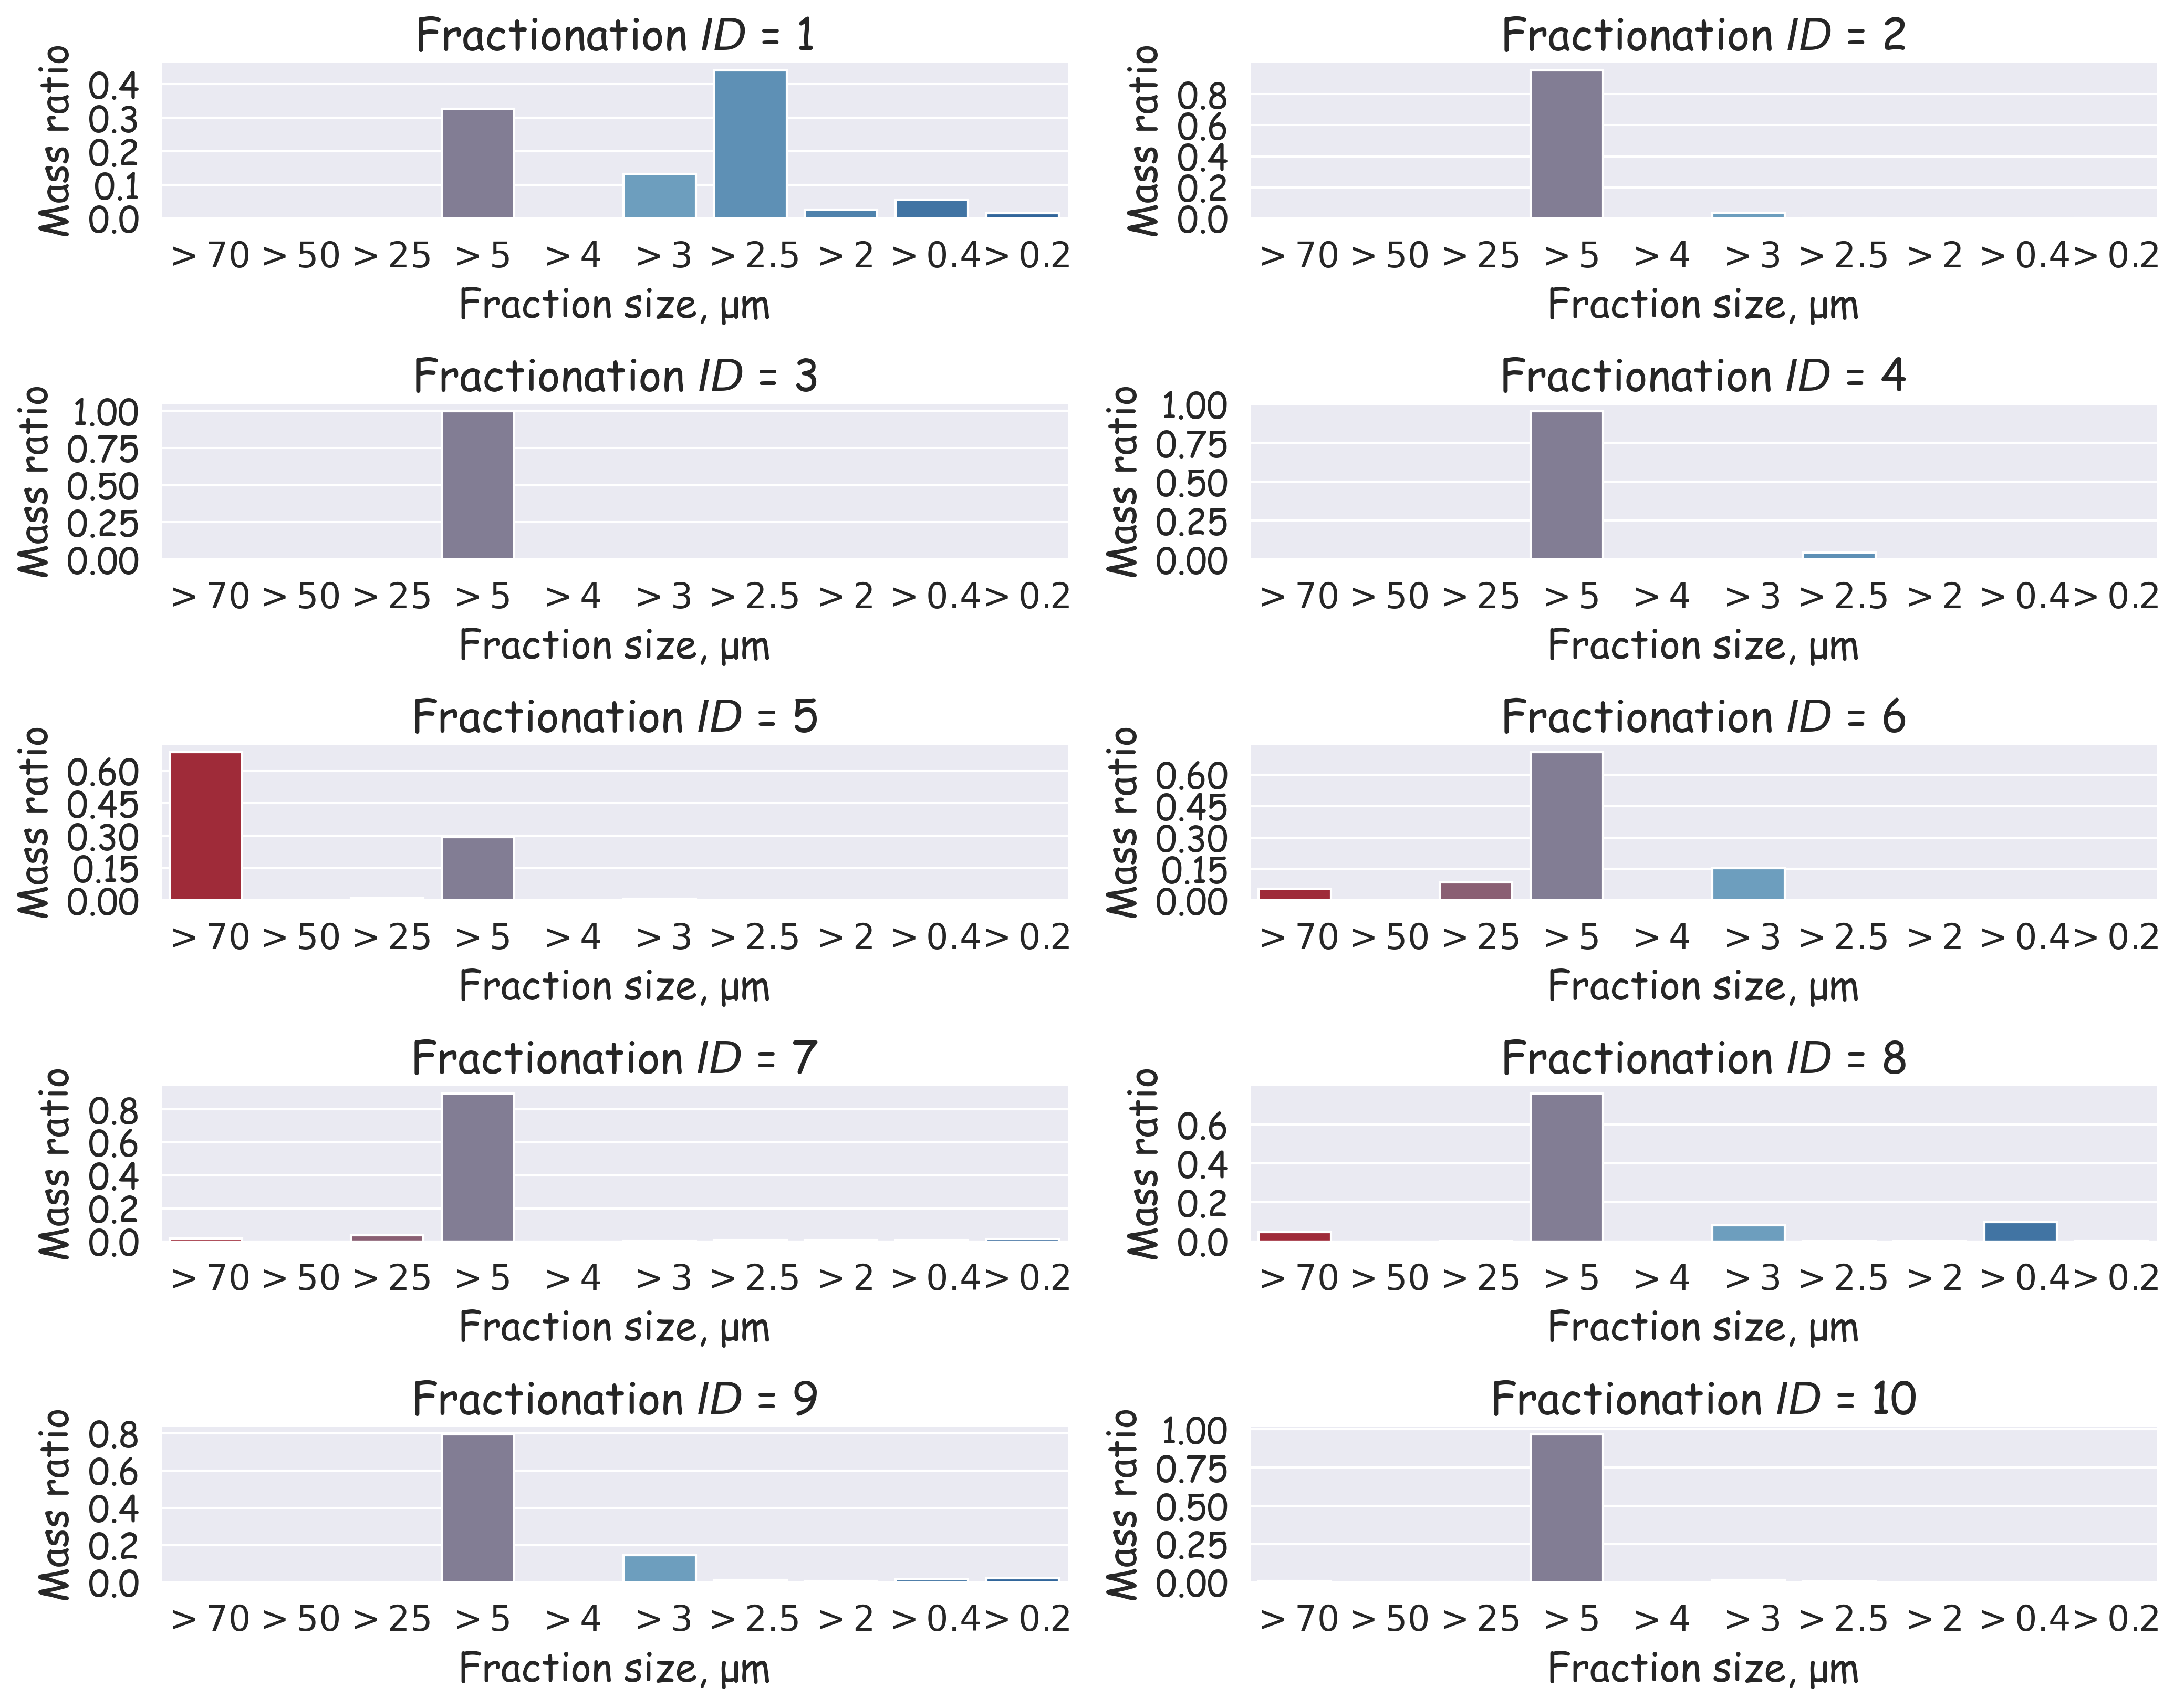

In [15]:
nrows, ncols = 5, 2
fig_w, fig_h = 7 * ncols, 2.2 * nrows
n_plots = len(fraction_ids)
fontsize = 20

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300)
gs = gridspec.GridSpec(nrows, ncols, figure=fig)
axes = []

rem = n_plots % ncols
offset = (ncols - rem) // 2 if (rem and n_plots > ncols) else 0

for i, fraction_id in enumerate(fraction_ids):
    row, col = divmod(i, ncols)
    if row == nrows - 1 and rem:
        col = offset + (i % ncols)

    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)

    subset = (
        fractions_ratios_df[fractions_ratios_df['fractionation_id'] == fraction_id]
        .sort_values('size')
    )
    sns.barplot(
        data=subset,
        x='size',
        y='ratio',
        ax=ax,
        order=size_order,
        palette=size_to_color
    )

    ax.set_title(f'Fractionation $ID$ = {fraction_id}', fontsize=fontsize)
    ax.set_xlabel('Fraction size, μm', fontsize=fontsize-2)
    ax.set_ylabel('Mass ratio', fontsize=fontsize-2)
    ax.tick_params(labelsize=fontsize-4)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))

plt.tight_layout()
plt.savefig(f'{path_to_save}/fractions_ratios_barplots.png', dpi=1800)
plt.show()

## Box plot

In [16]:
fontsize = 14

In [17]:
size_to_group = {
    '$>70$':  r'$d > 5$',
    '$>50$':  r'$d > 5$',
    '$>25$':  r'$d > 5$',
    '$>5$':   r'$d > 5$',
    '$>4$':   r'$2 < d \leq 5$',
    '$>3$':   r'$2 < d \leq 5$',
    '$>2.5$': r'$2 < d \leq 5$',
    '$>2$':   r'$2 < d \leq 5$',
    '$>0.4$': r'$d \leq 2$',
    '$>0.2$': r'$d \leq 2$'
}

fractions_ratios_df['group'] = fractions_ratios_df['size'].map(size_to_group)

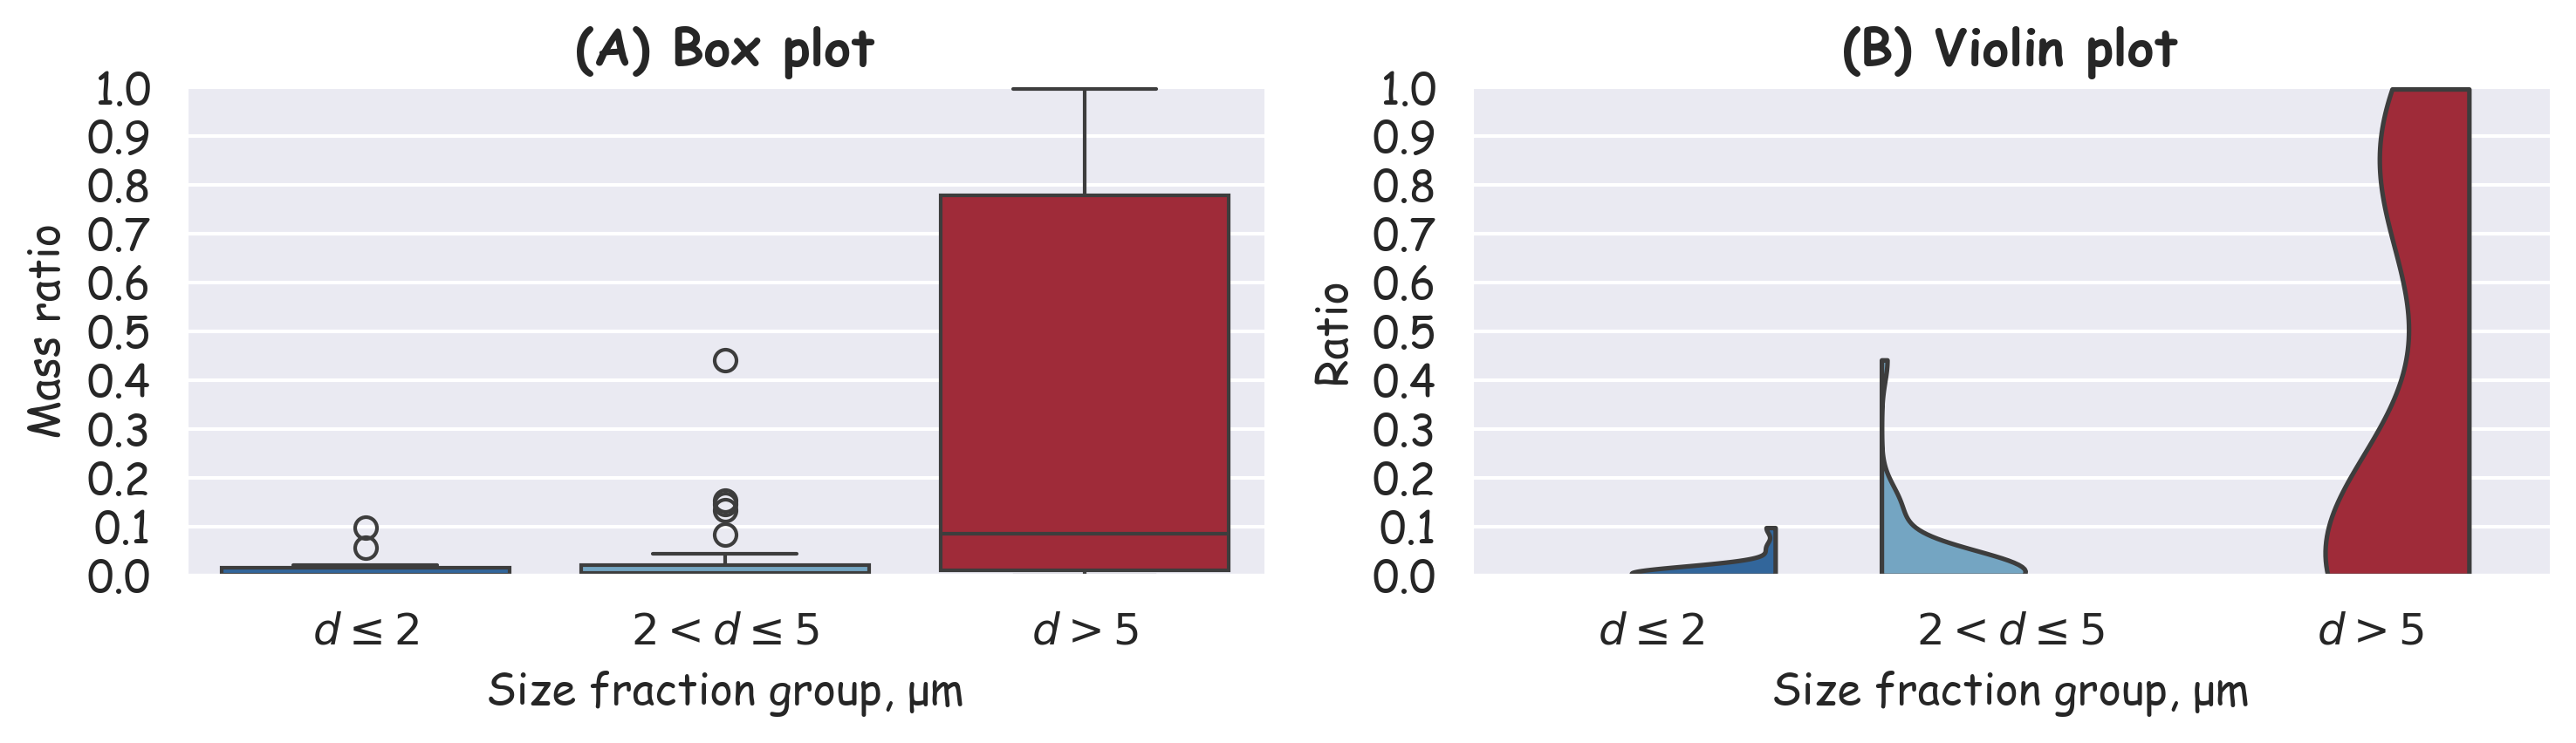

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=300)

# --- (A) Box plot ---
sns.boxplot(
    data=fractions_ratios_df,
    x='group',
    y='ratio',
    width=0.8,
    order=type_color_dict.keys(),
    palette=type_color_dict,
    ax=axes[0]
)
axes[0].set_title("(A) Box plot", fontsize=fontsize, fontweight='bold')
axes[0].set_xlabel("Size fraction group, μm", fontsize=fontsize-2)
axes[0].set_ylabel("Mass ratio", fontsize=fontsize-2)
axes[0].tick_params(labelsize=fontsize-2)
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
axes[0].set_ylim(0, 1)

# --- (B) Violin plot (half violins) ---
sns.violinplot(
    data=fractions_ratios_df,
    x='group',
    y='ratio',
    split=True,
    order=type_color_dict.keys(),
    palette=type_color_dict,
    ax=axes[1],
    cut=0,
    inner=None,
    bw_adjust=1.0
)

# превращаем в "половинчатые" виолины
for collection in axes[1].collections:
    path = collection.get_paths()[0]
    vertices = path.vertices
    vertices[:, 0] = vertices[:, 0].mean() + (vertices[:, 0] - vertices[:, 0].mean())/2

axes[1].set_title("(B) Violin plot", fontsize=fontsize, fontweight='bold')
axes[1].set_xlabel("Size fraction group, μm", fontsize=fontsize-2)
axes[1].set_ylabel("Ratio", fontsize=fontsize-2)
axes[1].tick_params(labelsize=fontsize-2)
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{path_to_save}/fractions_ratios_boxplot_violinplot.png', dpi=1800)
plt.show()